In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit


df = pd.read_csv("vendor_augmented_large.csv", parse_dates=["Date"])



In [2]:
# Choose one scenario and one region (US is a good default)
use = df[df["scenario_id"] == 0].copy()
A = use["Apple_US"].values
S = use["Samsung_US"].values
t = np.arange(len(use))  # daily index

In [3]:
#  (Optional) Normalize for stability
A0, S0 = A[0], S[0]
A_n = A / np.max(A)
S_n = S / np.max(S)

In [6]:
# Lotka–Volterra system
def lv(y, t, a, b, c, d):
    A, S = y
    dA = a*A - b*A*S
    dS = -c*S + d*A*S
    return [dA, dS]

def simulate(t, a, b, c, d, A0, S0):
    y0 = [A0, S0]
    sol = odeint(lv, y0, t, args=(a,b,c,d))
    return sol[:,0], sol[:,1]

# Initial conditions from normalized series
A_init = A_n[0]
S_init = S_n[0]

def fit_func(t, a, b, c, d):
    A_pred, S_pred = simulate(t, a, b, c, d, A_init, S_init)
    return np.concatenate([A_pred, S_pred])

ydata = np.concatenate([A_n, S_n])

# Use the same t (not tiled) and pass ydata accordingly
params, _ = curve_fit(
    lambda t, a, b, c, d: np.concatenate(simulate(t, a, b, c, d, A_init, S_init)),
    t,
    ydata,
    p0=[0.05, 0.01, 0.05, 0.01],
    maxfev=20000
)

A_pred, S_pred = simulate(t, *params, A_init, S_init)

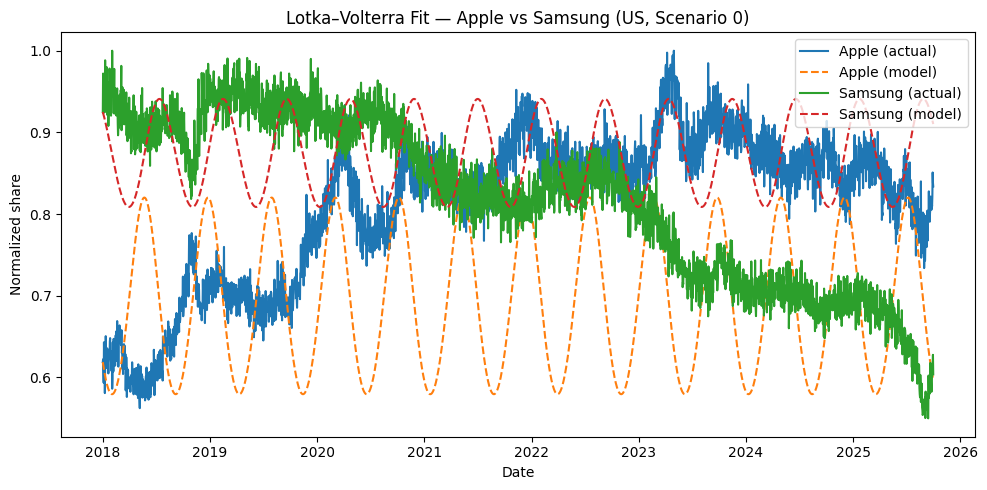

In [7]:
#  Plot actual vs model
plt.figure(figsize=(10,5))
plt.plot(use["Date"], A_n, label="Apple (actual)")
plt.plot(use["Date"], A_pred, "--", label="Apple (model)")
plt.plot(use["Date"], S_n, label="Samsung (actual)")
plt.plot(use["Date"], S_pred, "--", label="Samsung (model)")
plt.title("Lotka–Volterra Fit — Apple vs Samsung (US, Scenario 0)")
plt.xlabel("Date"); plt.ylabel("Normalized share")
plt.legend(); plt.tight_layout(); plt.show()